# 서로 다른 출처의 데이터셋
OULAD Dataset을 구글에 검색하면 두가지 Dataset이 존재한다.

- OULAD official site Dataset : https://analyse.kmi.open.ac.uk/open-dataset
- Kaggle Dataset : https://www.kaggle.com/datasets/anlgrbz/student-demographics-online-education-dataoulad/data

> 두개의 데이터셋은 같은 데이터일까?

-> 확인 결과 '거의' 같은 데이터셋이었다

차이점은 결측치를 official에서는 "?"로, Kaggle에서는 사전에 처리를 해놓아서 pandas에서 제공하는 na로 저장이 되어있다는 점이었다.

따라서 데이터셋에 대한 전반적인 통계정보가 있고 결측치도 표시가 되어있는 Kaggle을 기준으로 진행을 할 예정이지만,
사실 아래 검증코드 처럼 `read_csv()`를 하는 단계에서 결측치 표시를 해주어도 무방하다

In [1]:
# 확인 과정 (결측치 표시 통일 없이 검사하는 경우)
import pandas as pd

DATA_PATH = "../data/"
OFFICIAL_PATH = "../data/official_oulad/"
KAGGLE_PATH = "../data/kaggle_oulad/"
dataset = {}
# 1) 데이터 로드
for path in [OFFICIAL_PATH, KAGGLE_PATH]:
    courses = pd.read_csv(path + "courses.csv")
    assessments = pd.read_csv(path + "assessments.csv")
    vle = pd.read_csv(path + "vle.csv")
    student_info = pd.read_csv(path + "studentInfo.csv")
    student_registration = pd.read_csv(path + "studentRegistration.csv")
    student_assessment = pd.read_csv(path + "studentAssessment.csv")
    student_vle = pd.read_csv(path + "studentVle.csv")
    dataset[path] = [courses, assessments, vle, student_info, student_registration, student_assessment, student_vle]

for i in range(7):
    print(dataset[OFFICIAL_PATH][i].equals(dataset[KAGGLE_PATH][i])) # 결측치가 있는 데이터셋이라면 False, 없는 데이터셋이라면 True로 뜬다

True
False
False
False
False
False
True


In [2]:
import pandas as pd

DATA_PATH = "../data/"
OFFICIAL_PATH = "../data/official_oulad/"
KAGGLE_PATH = "../data/kaggle_oulad/"
dataset = {}
# 1) 데이터 로드
for path in [OFFICIAL_PATH, KAGGLE_PATH]:
    courses = pd.read_csv(path + "courses.csv",
    na_values=["?"],
    keep_default_na=True)
    assessments = pd.read_csv(path + "assessments.csv",
    na_values=["?"],
    keep_default_na=True)
    vle = pd.read_csv(path + "vle.csv",
    na_values=["?"],
    keep_default_na=True)
    student_info = pd.read_csv(path + "studentInfo.csv",
    na_values=["?"],
    keep_default_na=True)
    student_registration = pd.read_csv(path + "studentRegistration.csv",
    na_values=["?"],
    keep_default_na=True
)
    student_assessment = pd.read_csv(path + "studentAssessment.csv",
    na_values=["?"],
    keep_default_na=True
)
    student_vle = pd.read_csv(path + "studentVle.csv",
    na_values=["?"],
    keep_default_na=True
)
    dataset[path] = [courses, assessments, vle, student_info, student_registration, student_assessment, student_vle]

for i in range(7):
    print(dataset[OFFICIAL_PATH][i].equals(dataset[KAGGLE_PATH][i])) #결측치 여부와 상관 없이 모두 True로 뜬다

True
True
True
True
True
True
True


# 데이터 검증 수행
1. 대부분의 테이블 (`studentVle` 제외)은 key 중복 문제가 없다.
2. student_info와 student_registration은 학생-과목-회차 단위 기준 테이블로 사용할 수 있다.
3. date_unregistration 결측은 일반 missing이 아니라 등록 취소가 없는 상태로 해석해야 한다.
4. vle의 week_from/week_to는 결측률이 매우 높아 주요 feature로 쓰기 어렵다.
5. student_vle는 중복 문제가 크므로 반드시 정제 후 사용해야 한다.
   ```total rows:  10655280
   Exact duplicated rows: 787170 (7.39%)
   Duplicated by key: 2195960 (20.61%)
    ```
   - 완전히 같은행이 존재한다
      - Exact duplicated rows: 787,170 (click횟수까지 같은 행)
        - 이건 확실하게 duplicated data이기에 삭제하는게 맞다
      - Duplicated by key: 2,195,960 (같은 학생, 같은 모듈, 같은 날에 click횟수가 다른 행)
        - 이것도 문제인게 같은 날 같은 학생이 같은 모듈에서 어떻게 daily click count가 다를 수 있나
        - 로그 저장시 발생하는 오류?
        | 가능성              | 설명                                   |
        | ---------------- | ------------------------------------ |
        | 원본 데이터 품질 이슈     | 같은 학생-자료-날짜 단위의 기록이 여러 개 남아 있음       |
        | 숨겨진 세부 집계 단위가 존재 | 데이터에는 드러나지 않는 어떤 단위별로 나뉘어 저장되었을 수 있음 |
        - 클릭 기반 feature를 만들기 전 정제 기준에 대해 고민해야할 듯 sum vs. max vs. mean



#### The size of each dataset ####

courses (22, 3)
assessments (206, 6)
vle (6364, 6)
student_info (32593, 12)
student_registration (32593, 5)
student_assessment (173912, 5)
student_vle (10655280, 6)
#### Missing value check ####


The proportion of Missing values in courses dataset
code_module                   0.0
code_presentation             0.0
module_presentation_length    0.0
dtype: float64

The proportion of Missing values in assessments dataset
date                 0.053398
code_module          0.000000
code_presentation    0.000000
id_assessment        0.000000
assessment_type      0.000000
weight               0.000000
dtype: float64

The proportion of Missing values in vle dataset
week_from            0.823853
week_to              0.823853
code_module          0.000000
id_site              0.000000
activity_type        0.000000
code_presentation    0.000000
dtype: float64

The proportion of Missing values in student_info dataset
imd_band                0.034087
code_module

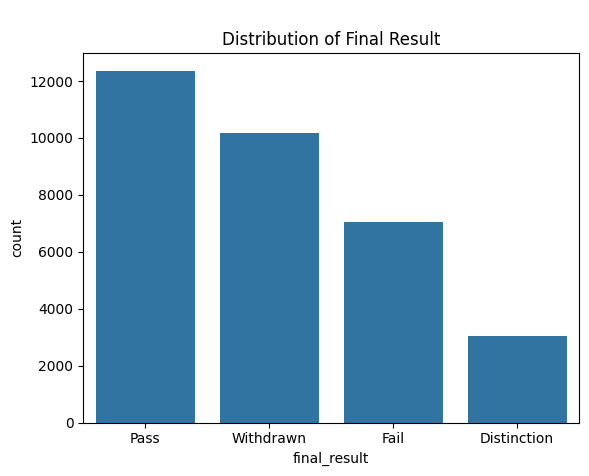

student_info duplication check : 0
student_registration duplication check : 0
#### Key duplication check ####

courses: duplicated by ['code_module', 'code_presentation'] = 0
assessments: duplicated by ['id_assessment'] = 0
vle: duplicated by ['id_site'] = 0
student_info: duplicated by ['code_module', 'code_presentation', 'id_student'] = 0
student_registration: duplicated by ['code_module', 'code_presentation', 'id_student'] = 0
student_assessment: duplicated by ['id_assessment', 'id_student'] = 0
student_vle: duplicated by ['code_module', 'code_presentation', 'id_student', 'id_site', 'date'] = 2195960


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터는 Kaggle을 사용
DATA_PATH = "../data/kaggle_oulad/"

# 1) 데이터 로드
courses = pd.read_csv(DATA_PATH + "courses.csv")
assessments = pd.read_csv(DATA_PATH + "assessments.csv")
vle = pd.read_csv(DATA_PATH + "vle.csv")
student_info = pd.read_csv(DATA_PATH + "studentInfo.csv")
student_registration = pd.read_csv(DATA_PATH + "studentRegistration.csv")
student_assessment = pd.read_csv(DATA_PATH + "studentAssessment.csv")
student_vle = pd.read_csv(DATA_PATH + "studentVle.csv")


# 2) 테이블로 한번에 핸들링할 예정
tables = {
    "courses": courses,
    "assessments": assessments,
    "vle": vle,
    "student_info": student_info,
    "student_registration": student_registration,
    "student_assessment": student_assessment,
    "student_vle": student_vle
}

# 테이블 크기 재확인
print("#### The size of each dataset ####\n")
for name, df in tables.items():
    print(name, df.shape)

# 3) 결측치 확인
print("#### Missing value check ####\n")
for name, df in tables.items():
    print(f"\nThe proportion of Missing values in {name} dataset")
    print(df.isna().mean().sort_values(ascending=False).head(10))

# 4) target distribution 확인
print("#### Target Distribution check ####\n")
print(student_info["final_result"].value_counts(dropna=False))
student_info["final_result"].value_counts()
student_info["final_result"].value_counts(normalize=True)
sns.countplot(data=student_info, x="final_result")
plt.title("\nDistribution of Final Result")
plt.show()

# 5) 동일 학생-과목-회차가 중복되는지 확인 (데이터 id의 유일성 점검)
KEY = ["code_module", "code_presentation", "id_student"]
# 한 학생당 반드시 한행이어야 함 -> 확인 결과 중복 없음
print(f"student_info duplication check : {student_info.duplicated(KEY).sum()}")
print(f"student_registration duplication check : {student_registration.duplicated(KEY).sum()}")

# 6) 각 table 별 Key 중복 확인
print("#### Key duplication check ####\n")

key_checks = {
    "courses": ["code_module", "code_presentation"],
    "assessments": ["id_assessment"],
    "vle": ["id_site"],
    "student_info": ["code_module", "code_presentation", "id_student"],
    "student_registration": ["code_module", "code_presentation", "id_student"],
    "student_assessment": ["id_assessment", "id_student"],
    "student_vle": ["code_module", "code_presentation", "id_student", "id_site", "date"]
}

for name, key in key_checks.items():
    df = tables[name]
    duplicated_count = df.duplicated(key).sum()
    print(f"{name}: duplicated by {key} = {duplicated_count}")

In [14]:
vle_key = ["code_module", "code_presentation", "id_student", "id_site", "date"]
print("total rows: ", student_vle.shape[0])
print("Exact duplicated rows:", student_vle.duplicated().sum())
print("Duplicated by key:", student_vle.duplicated(vle_key).sum())

total rows:  10655280
Exact duplicated rows: 787170
Duplicated by key: 2195960
